In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Define the paths to the Kaggle dataset
DATA_DIR = '/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

# Read the CSV file containing the bounding boxes and labels
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

print(f"Total annotations in CSV: {len(train_df)}")
print(f"Total unique images: {train_df['image_id'].nunique()}")

# Display the first 5 rows to see the data format
train_df.head()

Total annotations in CSV: 67914
Total unique images: 15000


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


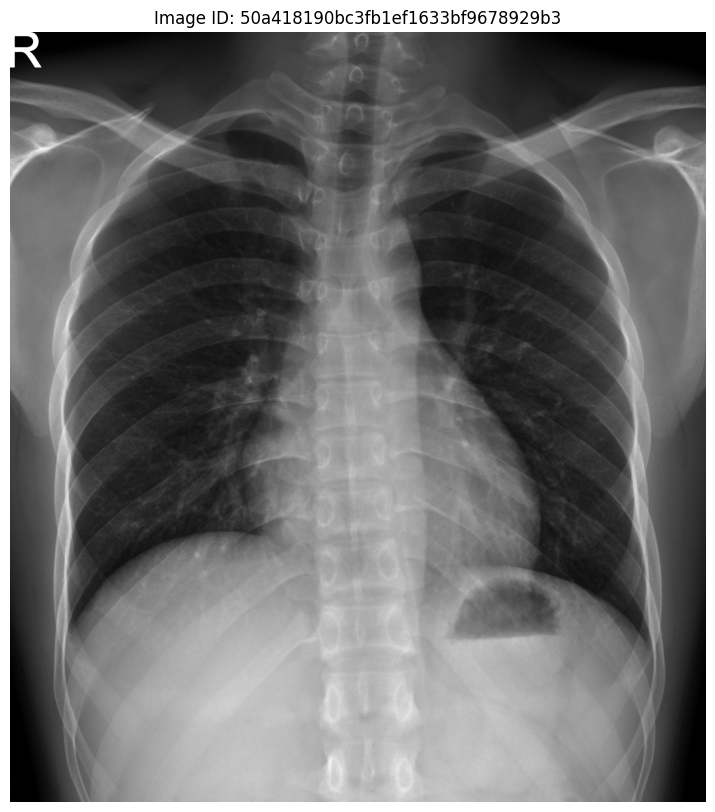

In [2]:
def plot_dicom_with_boxes(image_id, df, data_dir):
    # 1. Get the path to the specific DICOM file
    dicom_path = os.path.join(data_dir, f"{image_id}.dicom")
    
    # 2. Read the DICOM file using pydicom
    dicom = pydicom.dcmread(dicom_path)
    img = dicom.pixel_array
    
    # 3. Handle Photometric Interpretation (invert if necessary)
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        img = np.amax(img) - img
        
    # 4. Plot the image
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Image ID: {image_id}")
    
    # 5. Get all bounding boxes for this specific image from the dataframe
    boxes = df[df['image_id'] == image_id]
    
    # 6. Draw each bounding box
    for _, row in boxes.iterrows():
        # Class 14 usually means "No finding" in this dataset, so we skip it
        if row['class_id'] != 14: 
            x_min, y_min = row['x_min'], row['y_min']
            width = row['x_max'] - x_min
            height = row['y_max'] - y_min
            
            # Create a Rectangle patch
            rect = patches.Rectangle((x_min, y_min), width, height, 
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            
            # Add label text
            ax.text(x_min, y_min - 10, f"Class: {row['class_name']}", 
                    color='red', fontsize=12, backgroundcolor='white')

    plt.axis('off')
    plt.show()

# Test it out on the very first image in our dataframe!
sample_image_id = train_df['image_id'].iloc[0]
plot_dicom_with_boxes(sample_image_id, train_df, TRAIN_DIR)

In [3]:
from tqdm import tqdm

# Create a folder in Kaggle's working directory to save the new PNGs
OUTPUT_DIR = '/kaggle/working/processed_train'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def process_and_save_dicom(image_id, input_dir, output_dir, target_size=(512, 512)):
    # 1. Read DICOM
    dicom_path = os.path.join(input_dir, f"{image_id}.dicom")
    dicom = pydicom.dcmread(dicom_path)
    img = dicom.pixel_array.astype(np.float32)
    
    # 2. Handle Photometric Interpretation
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        img = np.amax(img) - img
        
    # 3. Intensity Normalization (Min-Max to 0-255)
    img = (img - np.min(img)) / (np.max(img) - np.min(img))
    img = (img * 255).astype(np.uint8)
    
    # 4. Light contrast enhancement - CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    
    # 5. Light denoising - Gaussian Blur
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    # 6. Resize
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    
    # 7. Save as PNG
    save_path = os.path.join(output_dir, f"{image_id}.png")
    cv2.imwrite(save_path, img)

# Get a list of unique image IDs
unique_images = train_df['image_id'].unique()

# TEST RUN: Let's only process the first 100 images to make sure it works!
print("Starting DICOM to PNG conversion...")
for img_id in tqdm(unique_images[:100]): 
    process_and_save_dicom(img_id, TRAIN_DIR, OUTPUT_DIR)
    
print(f"Test batch saved to {OUTPUT_DIR}")

Starting DICOM to PNG conversion...


100%|██████████| 100/100 [01:36<00:00,  1.04it/s]

Test batch saved to /kaggle/working/processed_train


In [4]:
import os
import pydicom
import pandas as pd
from tqdm import tqdm

# Define directories
LABELS_DIR = '/kaggle/working/processed_labels'
os.makedirs(LABELS_DIR, exist_ok=True)

def convert_to_yolo(df, data_dir, output_dir):
    print("Starting YOLO annotation conversion...")
    
    # Group the dataframe by image_id so we process one image at a time
    grouped = df.groupby('image_id')
    
    # Process only the first 100 images to match our test batch from the previous cell
    test_image_ids = df['image_id'].unique()[:100] 
    
    for img_id in tqdm(test_image_ids):
        # 1. Get original image dimensions from the DICOM file
        dicom_path = os.path.join(data_dir, f"{img_id}.dicom")
        dicom = pydicom.dcmread(dicom_path)
        img_height, img_width = dicom.Rows, dicom.Columns
        
        # 2. Get all annotations for this image
        annotations = grouped.get_group(img_id)
        
        # 3. Open a .txt file for this image
        label_path = os.path.join(output_dir, f"{img_id}.txt")
        with open(label_path, 'w') as f:
            for _, row in annotations.iterrows():
                class_id = int(row['class_id'])
                
                # Class 14 is "No finding". YOLO handles background images 
                # by simply having an empty .txt file.
                if class_id == 14:
                    continue 
                
                # 4. Extract original coordinates
                x_min, y_min = row['x_min'], row['y_min']
                x_max, y_max = row['x_max'], row['y_max']
                
                # 5. Calculate YOLO coordinates (normalized 0 to 1)
                x_center = ((x_min + x_max) / 2) / img_width
                y_center = ((y_min + y_max) / 2) / img_height
                bbox_width = (x_max - x_min) / img_width
                bbox_height = (y_max - y_min) / img_height
                
                # 6. Write to file: class_id x_center y_center width height
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# Run the conversion
convert_to_yolo(train_df, TRAIN_DIR, LABELS_DIR)
print(f"YOLO labels saved to {LABELS_DIR}")

Starting YOLO annotation conversion...


100%|██████████| 100/100 [00:00<00:00, 126.10it/s]

YOLO labels saved to /kaggle/working/processed_labels


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

# 1. Define YOLO directory structure
YOLO_DIR = '/kaggle/working/yolo_dataset'
for split in ['train', 'val']:
    for category in ['images', 'labels']:
        os.makedirs(os.path.join(YOLO_DIR, split, category), exist_ok=True)

# 2. Get unique image IDs we processed earlier
processed_images = [f.split('.')[0] for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')]

# 3. Perform a safe 80/20 Train/Validation Split
train_ids, val_ids = train_test_split(processed_images, test_size=0.2, random_state=42)

def move_files(image_ids, split_name):
    print(f"Moving files to {split_name} set...")
    for img_id in image_ids:
        # Source paths
        src_img = os.path.join(OUTPUT_DIR, f"{img_id}.png")
        src_label = os.path.join(LABELS_DIR, f"{img_id}.txt")
        
        # Destination paths
        dst_img = os.path.join(YOLO_DIR, split_name, 'images', f"{img_id}.png")
        dst_label = os.path.join(YOLO_DIR, split_name, 'labels', f"{img_id}.txt")
        
        # Move files if they exist
        if os.path.exists(src_img) and os.path.exists(src_label):
            shutil.copy(src_img, dst_img)
            shutil.copy(src_label, dst_label)

# 4. Execute the split
move_files(train_ids, 'train')
move_files(val_ids, 'val')

print(f"Split complete! Training images: {len(train_ids)} | Validation images: {len(val_ids)}")

Moving files to train set...
Moving files to val set...
Split complete! Training images: 80 | Validation images: 20


In [10]:
import albumentations as A

# Define the updated safe augmentation pipeline
transform = A.Compose([
    # Safe: Lungs are generally symmetrical
    A.HorizontalFlip(p=0.5), 
    
    # UPDATED: Removed 'mode' and 'cval' to rely on the new defaults (pads with black)
    # Safe: Simulates slight patient movement or misalignments
    A.Affine(translate_percent=0.05, scale=(0.95, 1.05), rotate=[-10, 10], p=0.5),
    
    # Safe: Adjusts X-ray exposure differences
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    
    # Safe: Mildly simulates different tissue densities or breathing states
    A.ElasticTransform(alpha=1, sigma=50, p=0.2)
], 
# CRITICAL: Tell Albumentations we are using YOLO format bounding boxes
bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print("Augmentation pipeline initialized perfectly!")

Augmentation pipeline initialized perfectly!
